### Введение

**1. Примеры применения машинного обучения в жизни**

1. **Рекомендательные системы**
   Например, YouTube или Netflix предлагают контент на основе предыдущих просмотров.
   **Польза:** экономия времени и персонализация.

2. **Фильтрация спама**
   Почтовые сервисы автоматически определяют спам.
   **Польза:** защита от нежелательных писем.

3. **Кредитный скоринг**
   Банк оценивает вероятность возврата кредита.
   **Польза:** снижение рисков.

4. **Медицинская диагностика**
   Анализ данных пациента и снимков.
   **Польза:** более точная и быстрая диагностика.

5. **Прогнозирование цен**
   Например, стоимость аренды жилья.
   **Польза:** помогает ориентироваться на рынке.

---

**2. Классификация задач**

* Рекомендательные системы → **регрессия / ранжирование**
* Спам → **бинарная классификация**
* Кредитный скоринг → **бинарная классификация**
* Медицинская диагностика → **классификация**
* Прогнозирование цен → **регрессия**

---

**3. Разница между multiclass и multilabel**

* **Multiclass** — объект относится только к одному классу
  (например, письмо либо спам, либо нет)

* **Multilabel** — объект может иметь несколько меток одновременно
  (например, фильм может быть и комедией, и драмой)

---

**4. Пример с ценами на жильё**

Это задача **регрессии**, потому что предсказывается числовое значение.

Регрессию можно преобразовать в классификацию, если разбить значения на категории (например: низкая, средняя, высокая цена).

Но при этом теряется точность, поэтому чаще используют регрессию.


In [1]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm
import scipy
import statsmodels
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
df = pd.read_json('./data/train.json')

In [3]:
df.shape

(49352, 15)

In [4]:
df.columns.tolist()

['bathrooms',
 'bedrooms',
 'building_id',
 'created',
 'description',
 'display_address',
 'features',
 'latitude',
 'listing_id',
 'longitude',
 'manager_id',
 'photos',
 'price',
 'street_address',
 'interest_level']

Target column is price

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [6]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
df.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [8]:
df.isnull().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

There are no missing values

In [9]:
df = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]

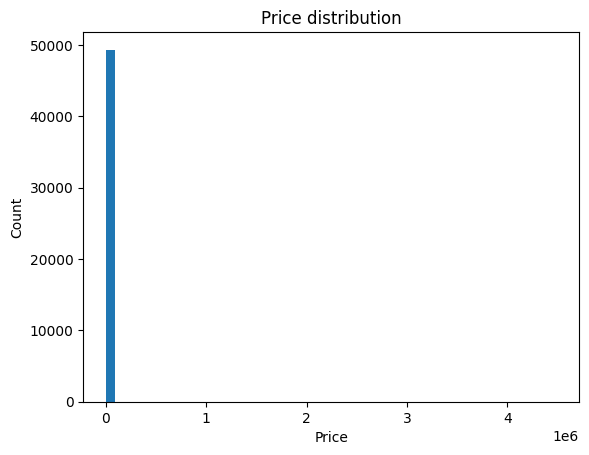

In [10]:

plt.hist(df['price'], bins=50)
plt.title('Price distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

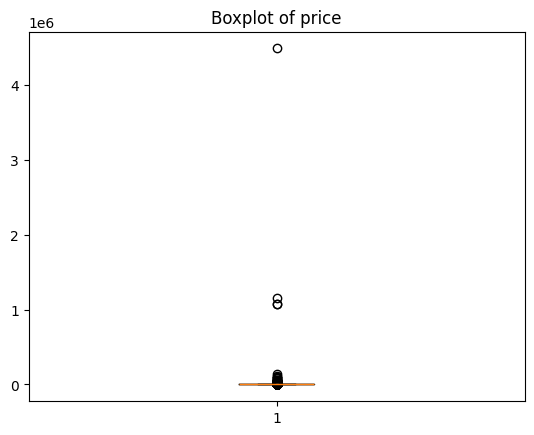

In [11]:
plt.boxplot(df['price'])
plt.title('Boxplot of price')
plt.show()

In [12]:
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

df = df[(df['price'] >= lower) & (df['price'] <= upper)]

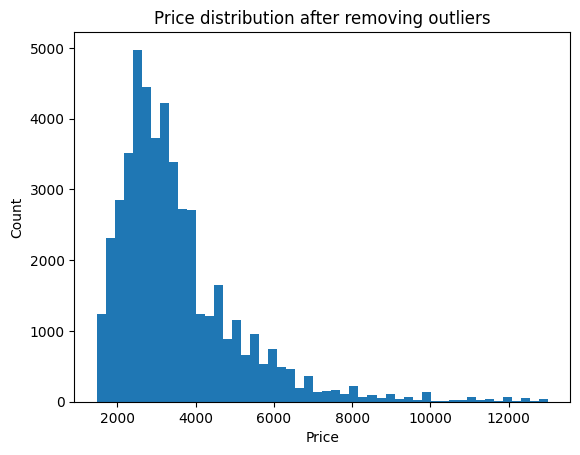

In [13]:
plt.hist(df['price'], bins=50)
plt.title('Price distribution after removing outliers')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [14]:
df['interest_level'].dtype

dtype('O')

In [15]:
df['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [16]:
mapping = {'low': 0, 'medium': 1, 'high': 2}
df['interest_level'] = df['interest_level'].map(mapping)

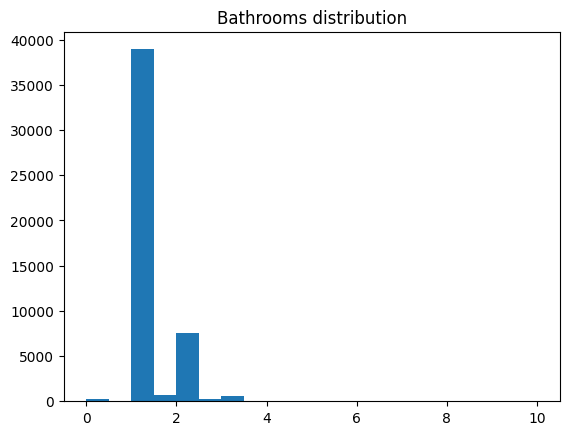

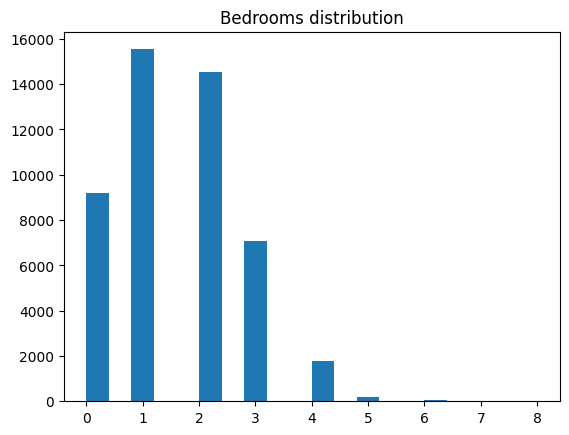

In [17]:

plt.hist(df['bathrooms'], bins=20)
plt.title('Bathrooms distribution')
plt.show()

plt.hist(df['bedrooms'], bins=20)
plt.title('Bedrooms distribution')
plt.show()

In [18]:
corr = df.corr(numeric_only=True)
corr

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


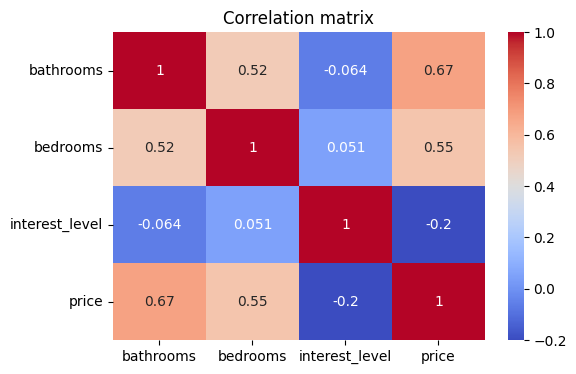

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

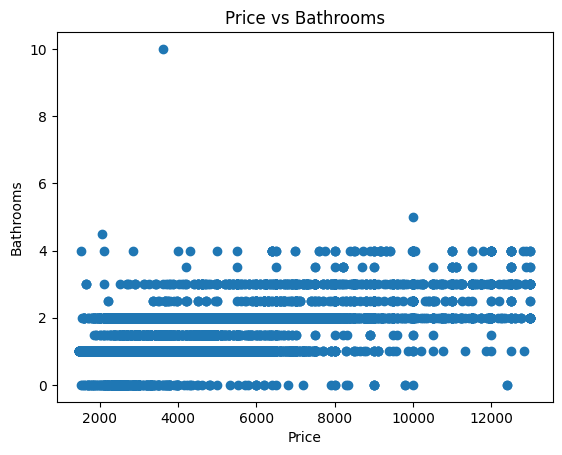

In [20]:
plt.scatter(df['price'], df['bathrooms'])
plt.xlabel('Price')
plt.ylabel('Bathrooms')
plt.title('Price vs Bathrooms')
plt.show()

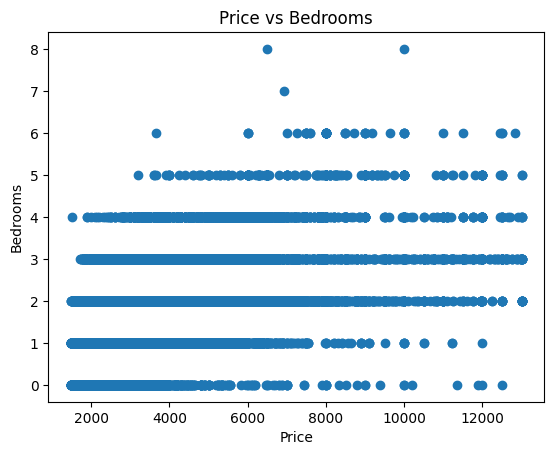

In [21]:
plt.scatter(df['price'], df['bedrooms'])
plt.xlabel('Price')
plt.ylabel('Bedrooms')
plt.title('Price vs Bedrooms')
plt.show()

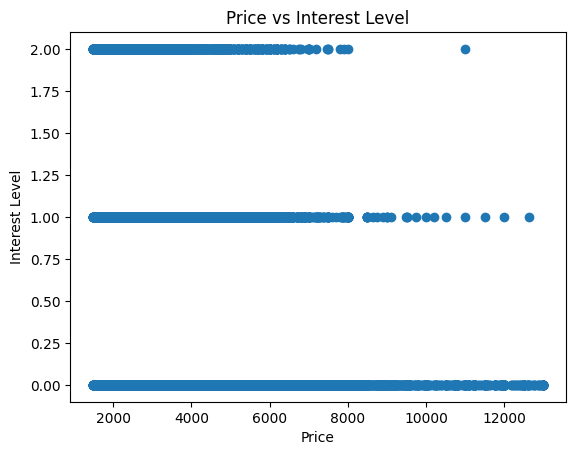

In [22]:
plt.scatter(df['price'], df['interest_level'])
plt.xlabel('Price')
plt.ylabel('Interest Level')
plt.title('Price vs Interest Level')
plt.show()

In [23]:
df['bathrooms_squared'] = df['bathrooms'] ** 2
df['bedrooms_squared'] = df['bedrooms'] ** 2
df['interest_level_squared'] = df['interest_level'] ** 2

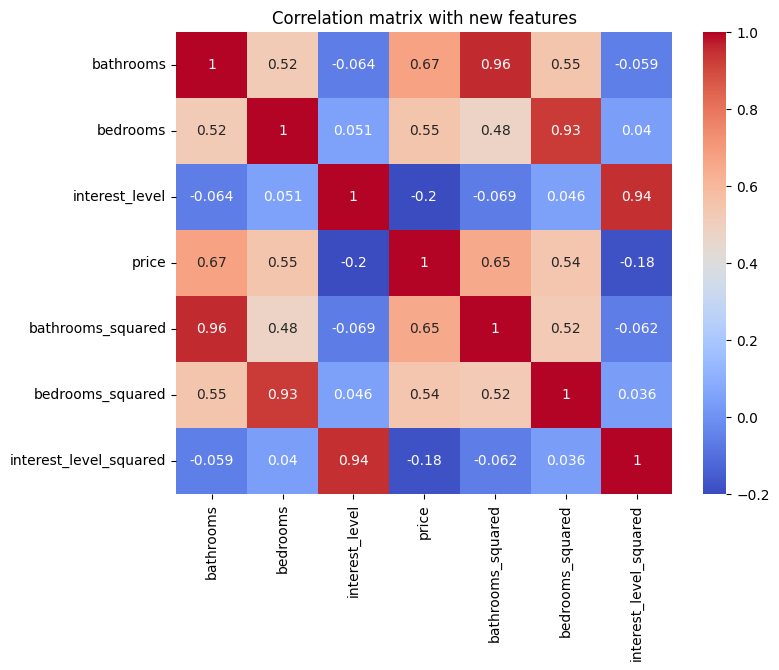

In [24]:
corr_new = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_new, annot=True, cmap='coolwarm')
plt.title('Correlation matrix with new features')
plt.show()

In [25]:
X = df[['bathrooms', 'bedrooms']]
y = df['price']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

In [27]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=10)

In [28]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [29]:
print(X_train.shape)
print(X_train_poly.shape)
print(X_test.shape)
print(X_test_poly.shape)

(38703, 2)
(38703, 66)
(9676, 2)
(9676, 66)


In [30]:
print("Original train shape:", X_train.shape)
print("Polynomial train shape:", X_train_poly.shape)
print("Original test shape:", X_test.shape)
print("Polynomial test shape:", X_test_poly.shape)


Original train shape: (38703, 2)
Polynomial train shape: (38703, 66)
Original test shape: (9676, 2)
Polynomial test shape: (9676, 66)


Создание таблиц для моделей

In [31]:
import pandas as pd

result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [32]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_poly, y_train)

LinearRegression()

In [33]:
y_train_pred = model_lr.predict(X_train_poly)
y_test_pred = model_lr.predict(X_test_poly)

/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/maksim/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: Runti

In [34]:
df['lr_pred'] = None
df.loc[X_train.index, 'lr_pred'] = y_train_pred
df.loc[X_test.index, 'lr_pred'] = y_test_pred

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [36]:
result_MAE.loc[len(result_MAE)] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', rmse_train, rmse_test]

In [37]:
from sklearn.tree import DecisionTreeRegressor

model_tree = DecisionTreeRegressor(random_state=21)
model_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=21)

In [38]:
y_train_pred = model_tree.predict(X_train)
y_test_pred = model_tree.predict(X_test)

In [39]:
df['tree_pred'] = None
df.loc[X_train.index, 'tree_pred'] = y_train_pred
df.loc[X_test.index, 'tree_pred'] = y_test_pred

In [40]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [41]:
result_MAE.loc[len(result_MAE)] = ['decision_tree', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', rmse_train, rmse_test]

Naive model

In [42]:
mean_value = y_train.mean()

y_train_pred = [mean_value] * len(y_train)
y_test_pred = [mean_value] * len(y_test)

In [43]:
df['naive_mean_pred'] = None
df.loc[X_train.index, 'naive_mean_pred'] = mean_value
df.loc[X_test.index, 'naive_mean_pred'] = mean_value

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [45]:
result_MAE.loc[len(result_MAE)] = ['naive_mean', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', rmse_train, rmse_test]

Median

In [46]:
median_value = y_train.median()

y_train_pred = [median_value] * len(y_train)
y_test_pred = [median_value] * len(y_test)

In [47]:
df['naive_median_pred'] = None
df.loc[X_train.index, 'naive_median_pred'] = median_value
df.loc[X_test.index, 'naive_median_pred'] = median_value

In [48]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [49]:
result_MAE.loc[len(result_MAE)] = ['naive_median', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', rmse_train, rmse_test]

In [50]:
print(result_MAE)
print()
print(result_RMSE)

               model        train         test
0  linear_regression   756.726509   759.829899
1      decision_tree   756.704419   753.850437
2         naive_mean  1140.445303  1136.621987
3       naive_median  1087.459008  1081.216618

               model        train         test
0  linear_regression  1079.066347  1247.299085
1      decision_tree  1078.967775  1073.521803
2         naive_mean  1598.460491  1594.392461
3       naive_median  1645.459174  1639.336503
